# Real data — vortex-centre clustering analysis

**Reference:** `project_roadmap.md` Steps 3 & 5b · Kashyap, Kiran & Gupta, arXiv:2507.04890v2.
Builds on notebooks 01–04 (synthetic validation of the Voronoi / grid-binning / K-means pipeline
and its R²/KS closeness metrics).

**Data:** `isotropic1024_slice.npz` — a 1024×1024 slice of the Johns Hopkins **3-D forced isotropic
turbulence** dataset, holding velocity components `u, v, w` on a periodic `[0, 2π]²` grid
(`dx = 2π/1024`). This is *passive* turbulence, a different physical system from the paper's 2-D
active turbulence, so this notebook is a **methods demonstration**: we apply our validated
clustering pipeline to a real turbulent field and ask *how uniform are its vortex centres?*

**Plan (as agreed):**
1. Extract vortex centres from the out-of-plane vorticity ω_z by the **simple peak method** and
   **plot the centres**.
2. Run **Voronoi**, **grid-binning**, and **K-means** on the centres and produce their PDFs.
3. Quantify the **degree of uniformity** with **R², KS, and a z-score** (plus CV/IQR ratios),
   measured against both a matched-N **CSR Monte-Carlo null** and the analytic null where one exists.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from scipy.spatial import Voronoi
from scipy.cluster.vq import kmeans2
from scipy.stats import gamma, poisson, kstest, ks_2samp

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ----- tunable parameters -----
K_SIGMA   = 2.0     # noise threshold: keep peaks with |w_z| > mean + K_SIGMA*std   (top-level knob)
PEAK_SEP  = 7       # min peak separation (max-filter footprint, grid points)
MARGIN_F  = 0.04    # Voronoi interior margin as a fraction of the domain
LAMBDA_T  = 8.0     # target mean count per grid cell (sets grid resolution)
KMEANS_K  = 8       # number of K-means clusters
N_NULL    = 150     # CSR Monte-Carlo null realisations
B_PV      = 3.57    # 2D Poisson-Voronoi gamma shape


## 1. Vorticity field and vortex-centre extraction

ω_z = ∂v/∂x − ∂u/∂y by **periodic central differences** (`np.roll`). Centres are the local maxima
of |ω_z| within a `PEAK_SEP×PEAK_SEP` neighbourhood that also exceed the noise threshold
`mean + K_SIGMA·std` — i.e. genuine intense vortices, with weak background fluctuations removed.


In [2]:
d = np.load("isotropic1024_slice.npz")
u, v = d["u"], d["v"]
nx = u.shape[0]
Ldom = 2.0 * np.pi
dx = Ldom / nx

# out-of-plane vorticity, periodic central differences (axis0=y/rows, axis1=x/cols)
dvdx = (np.roll(v, -1, axis=1) - np.roll(v, 1, axis=1)) / (2 * dx)
dudy = (np.roll(u, -1, axis=0) - np.roll(u, 1, axis=0)) / (2 * dx)
wz = dvdx - dudy

def extract_centres(field, k_sigma=K_SIGMA, sep=PEAK_SEP):
    mag = np.abs(field)
    thr = mag.mean() + k_sigma * mag.std()
    is_peak = (maximum_filter(mag, size=sep) == mag) & (mag > thr)
    iy, ix = np.nonzero(is_peak)
    return np.column_stack([ix * dx, iy * dx])     # physical (x, y) in [0, Ldom]

centres = extract_centres(wz)
N = len(centres)
print(f"grid {nx}x{nx},  domain [0, 2pi]^2,  dx={dx:.5f}")
print(f"|w_z|: mean={np.abs(wz).mean():.3f}  std={np.abs(wz).std():.3f}  "
      f"threshold={np.abs(wz).mean()+K_SIGMA*np.abs(wz).std():.3f}")
print(f"extracted N = {N} vortex centres at k={K_SIGMA}")


grid 1024x1024,  domain [0, 2pi]^2,  dx=0.00614
|w_z|: mean=6.416  std=6.298  threshold=19.012
extracted N = 3186 vortex centres at k=2.0


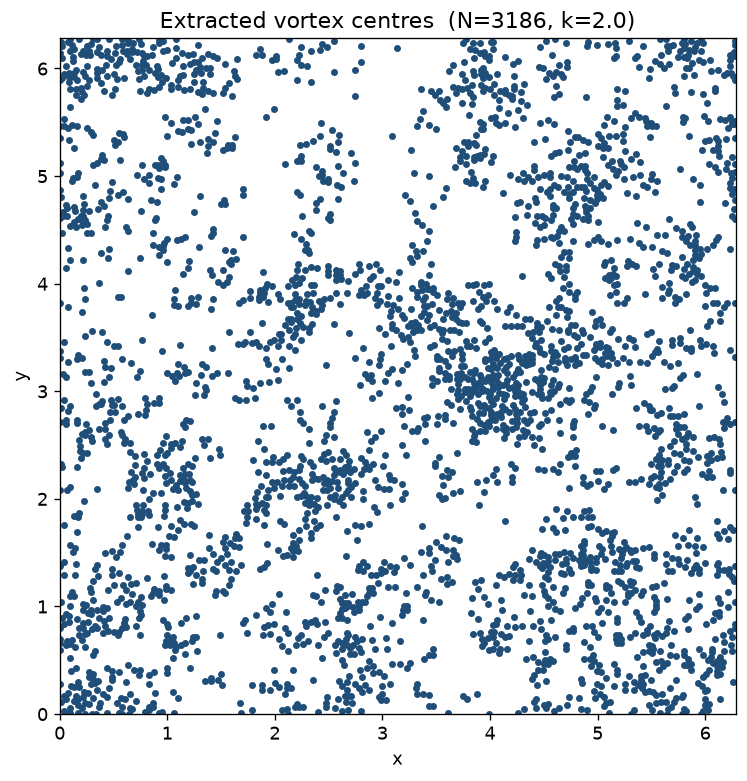

In [3]:
# Part 1 deliverable: scatter of the extracted vortex centres
fig, ax = plt.subplots(figsize=(6.4, 6.4), constrained_layout=True)
ax.scatter(centres[:, 0], centres[:, 1], s=10, color="#1f4e79")
ax.set(title=f"Extracted vortex centres  (N={N}, k={K_SIGMA})",
       xlim=(0, Ldom), ylim=(0, Ldom), xlabel="x", ylabel="y")
ax.set_aspect("equal")
plt.show()


In [4]:
# robustness: how many centres at looser / stricter thresholds
for kk in (1.5, 2.0, 2.5):
    print(f"k = {kk}:  N = {len(extract_centres(wz, k_sigma=kk))} centres")


k = 1.5:  N = 4295 centres
k = 2.0:  N = 3186 centres
k = 2.5:  N = 2356 centres


## 2. The three methods + reference nulls

Helper functions (reused from notebooks 01–04, adapted to the `[0, 2π]²` domain). We then build a
**matched-N CSR Monte-Carlo null**: `N_NULL` independent sets of `N` points placed uniformly at
random in the same domain. Every method runs on the real centres *and* on this null ensemble, so
each statistic is judged against what spatial randomness actually produces at this sample size.


In [5]:
margin = MARGIN_F * Ldom

def shoelace(p):
    x, y = p[:, 0], p[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def voronoi_areas(points):
    '''normalised interior Voronoi cell areas'''
    vor = Voronoi(points)
    lo, hi = margin, Ldom - margin
    a = []
    for ridx in vor.point_region:
        r = vor.regions[ridx]
        if len(r) == 0 or -1 in r:
            continue
        w = vor.vertices[r]
        if (w[:, 0] < lo).any() or (w[:, 0] > hi).any() or (w[:, 1] < lo).any() or (w[:, 1] > hi).any():
            continue
        a.append(shoelace(w))
    a = np.asarray(a)
    return a / a.mean()

def grid_counts(points, num_bins):
    H, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=num_bins, range=[[0, Ldom], [0, Ldom]])
    return H.ravel()

def kmeans_dist(points, k=KMEANS_K, seed=0):
    cen, lab = kmeans2(points.astype(float), k, minit="++", seed=seed)
    dd = np.linalg.norm(points - cen[lab], axis=1)
    return dd / dd.mean()

NUM_BINS = max(4, int(round(np.sqrt(N / LAMBDA_T))))
print(f"grid: {NUM_BINS}x{NUM_BINS} cells -> lambda = {N/NUM_BINS**2:.2f} points/cell")


grid: 20x20 cells -> lambda = 7.96 points/cell


In [6]:
# matched-N CSR Monte-Carlo null: run all three methods on each realisation
csr_area, csr_cnt, csr_dist = [], [], []
cv_area, iqr_area = [], []
cv_chi,  iqr_chi  = [], []
cv_dist, iqr_dist = [], []

def cv(x):  return x.std() / x.mean()
def iqr(x): return np.subtract(*np.percentile(x, [75, 25]))

for i in range(N_NULL):
    p = rng.uniform(0, Ldom, size=(N, 2))
    a = voronoi_areas(p);            csr_area.append(a)
    c = grid_counts(p, NUM_BINS); chi = c / c.mean(); csr_cnt.append(c)
    dd = kmeans_dist(p, seed=i);     csr_dist.append(dd)
    cv_area.append(cv(a));   iqr_area.append(iqr(a))
    cv_chi.append(cv(chi));  iqr_chi.append(iqr(chi))
    cv_dist.append(cv(dd));  iqr_dist.append(iqr(dd))

csr_area = np.concatenate(csr_area)
csr_cnt  = np.concatenate(csr_cnt)
csr_dist = np.concatenate(csr_dist)
print(f"CSR null pooled: {csr_area.size} areas, {csr_cnt.size} counts, {csr_dist.size} distances "
      f"over {N_NULL} realisations of N={N}")


CSR null pooled: 384826 areas, 60000 counts, 477900 distances over 150 realisations of N=3186


### Closeness machinery (R², KS, z-score)

`r2_density` compares two density curves on shared bins; `zscore` says how many CSR-null standard
deviations the real CV (or IQR) sits away from the null mean — turning "looks broader" into a
significance.


In [7]:
def r2_density(emp, ref):
    ss_res = np.sum((emp - ref) ** 2)
    ss_tot = np.sum((emp - emp.mean()) ** 2)
    return 1 - ss_res / ss_tot

def zscore(real_val, null_vals):
    null_vals = np.asarray(null_vals)
    return (real_val - null_vals.mean()) / null_vals.std()


## Method A — Voronoi cell area

Real normalised areas vs. (i) the analytic Poisson–Voronoi gamma and (ii) the CSR null.


In [8]:
area_real = voronoi_areas(centres)
xmax = max(np.quantile(area_real, 0.99), np.quantile(csr_area, 0.99))
edges = np.linspace(0, xmax, 36); ctr = 0.5*(edges[:-1]+edges[1:])

emp_real, _ = np.histogram(area_real, bins=edges, density=True)
emp_csr,  _ = np.histogram(csr_area,  bins=edges, density=True)
theo_pv = gamma.pdf(ctr, a=B_PV, scale=1/B_PV)

vor_R2_pv  = r2_density(emp_real, theo_pv)
vor_R2_csr = r2_density(emp_real, emp_csr)
vor_ks_pv  = kstest(area_real, lambda x: gamma.cdf(x, a=B_PV, scale=1/B_PV))
vor_ks_csr = ks_2samp(area_real, csr_area)
vor_z_cv   = zscore(cv(area_real), cv_area)
vor_z_iqr  = zscore(iqr(area_real), iqr_area)

print(f"Voronoi  R2(gamma)={vor_R2_pv:.3f}  R2(CSR)={vor_R2_csr:.3f}  "
      f"KS_p(CSR)={vor_ks_csr.pvalue:.2e}")
print(f"         CV real={cv(area_real):.3f} vs CSR={np.mean(cv_area):.3f}  "
      f"(ratio {cv(area_real)/np.mean(cv_area):.2f}, z={vor_z_cv:.1f})")
print(f"         IQR real={iqr(area_real):.3f} vs CSR={np.mean(iqr_area):.3f} "
      f"(ratio {iqr(area_real)/np.mean(iqr_area):.2f}, z={vor_z_iqr:.1f})")


Voronoi  R2(gamma)=0.516  R2(CSR)=0.525  KS_p(CSR)=3.91e-109
         CV real=1.059 vs CSR=0.531  (ratio 2.00, z=48.1)
         IQR real=0.827 vs CSR=0.682 (ratio 1.21, z=8.1)


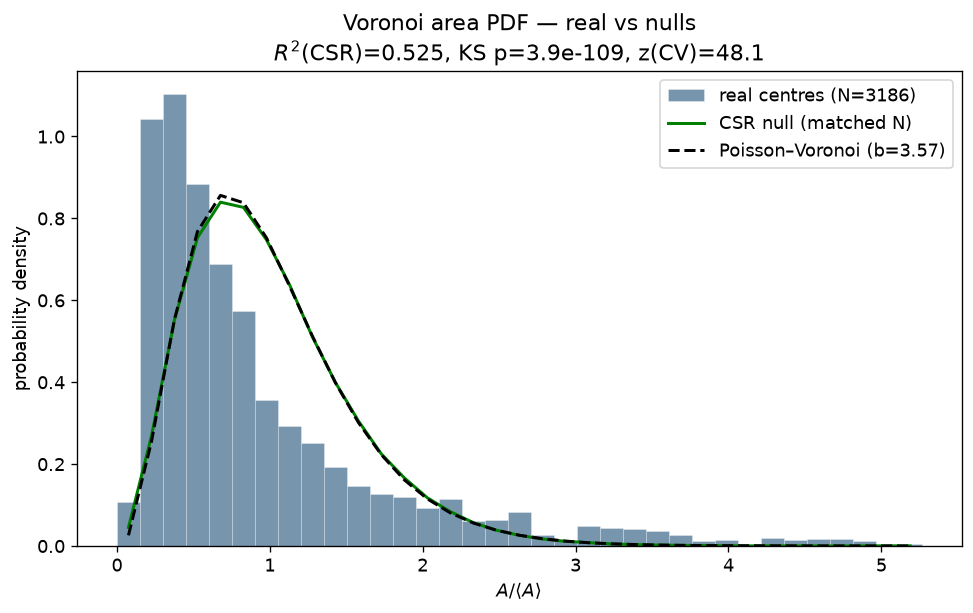

In [9]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.hist(area_real, bins=edges, density=True, color="#1f4e79", alpha=0.6,
        edgecolor="white", linewidth=0.3, label=f"real centres (N={N})")
ax.plot(ctr, emp_csr, color="green", lw=1.8, label="CSR null (matched N)")
ax.plot(ctr, theo_pv, "k--", lw=1.8, label=f"Poisson–Voronoi (b={B_PV})")
ax.set(title=f"Voronoi area PDF — real vs nulls\n"
             f"$R^2$(CSR)={vor_R2_csr:.3f}, KS p={vor_ks_csr.pvalue:.1e}, z(CV)={vor_z_cv:.1f}",
       xlabel=r"$A/\langle A\rangle$", ylabel="probability density")
ax.legend()
plt.show()


## Method B — Grid-binning

Real occupancy counts vs. (i) the analytic Poisson PMF and (ii) the CSR null.


In [10]:
cnt_real = grid_counts(centres, NUM_BINS)
chi_real = cnt_real / cnt_real.mean()
lam = cnt_real.mean()

kmax = int(max(cnt_real.max(), csr_cnt.max()))
ks_support = np.arange(0, kmax + 1)
pmf_real = np.array([(cnt_real == k).mean() for k in ks_support])
pmf_csr  = np.array([(csr_cnt  == k).mean() for k in ks_support])
pmf_pois = poisson.pmf(ks_support, lam)

grid_R2_pois = r2_density(pmf_real, pmf_pois)
grid_R2_csr  = r2_density(pmf_real, pmf_csr)
grid_ks_csr  = ks_2samp(cnt_real, csr_cnt)
grid_z_cv    = zscore(cv(chi_real), cv_chi)
grid_z_iqr   = zscore(iqr(chi_real), iqr_chi)

print(f"Grid     lambda={lam:.2f}  R2(Poisson)={grid_R2_pois:.3f}  R2(CSR)={grid_R2_csr:.3f}  "
      f"KS_p(CSR)={grid_ks_csr.pvalue:.2e}")
print(f"         CV(chi) real={cv(chi_real):.3f} vs CSR={np.mean(cv_chi):.3f}  "
      f"(ratio {cv(chi_real)/np.mean(cv_chi):.2f}, z={grid_z_cv:.1f})")


Grid     lambda=7.96  R2(Poisson)=-0.405  R2(CSR)=-0.386  KS_p(CSR)=2.02e-21
         CV(chi) real=0.761 vs CSR=0.355  (ratio 2.14, z=31.4)


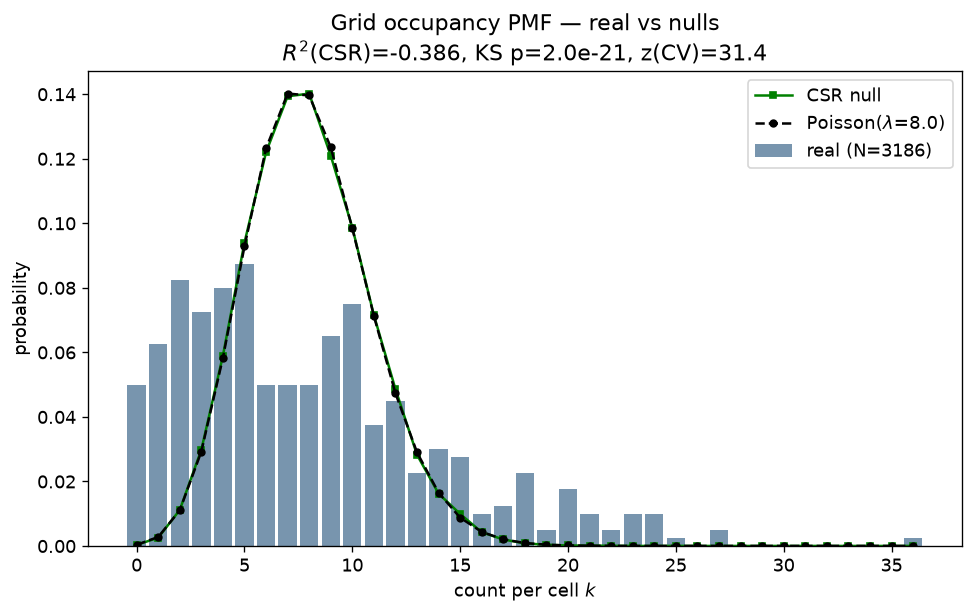

In [11]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.bar(ks_support, pmf_real, width=0.85, color="#1f4e79", alpha=0.6, label=f"real (N={N})")
ax.plot(ks_support, pmf_csr,  color="green", marker="s", ms=4, lw=1.5, label="CSR null")
ax.plot(ks_support, pmf_pois, "k--o", ms=4, lw=1.5, label=f"Poisson($\\lambda$={lam:.1f})")
ax.set(title=f"Grid occupancy PMF — real vs nulls\n"
             f"$R^2$(CSR)={grid_R2_csr:.3f}, KS p={grid_ks_csr.pvalue:.1e}, z(CV)={grid_z_cv:.1f}",
       xlabel="count per cell $k$", ylabel="probability")
ax.legend()
plt.show()


## Method C — K-means point-to-centroid distance

Real normalised distances vs. the CSR null (no closed-form null exists for this statistic).


K-means (k=8)  R2(CSR)=0.932  KS_p(CSR)=1.63e-02
         CV real=0.419 vs CSR=0.395  (ratio 1.06, z=2.2)


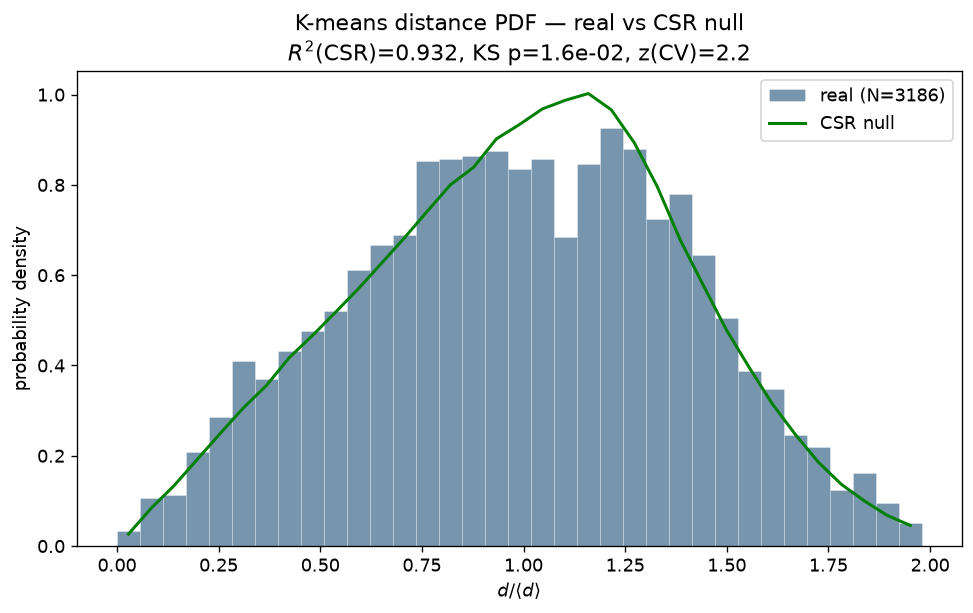

In [12]:
dist_real = kmeans_dist(centres, seed=0)
dmax = max(np.quantile(dist_real, 0.99), np.quantile(csr_dist, 0.99))
de = np.linspace(0, dmax, 36); dc = 0.5*(de[:-1]+de[1:])
demp_real, _ = np.histogram(dist_real, bins=de, density=True)
demp_csr,  _ = np.histogram(csr_dist,  bins=de, density=True)

km_R2_csr = r2_density(demp_real, demp_csr)
km_ks_csr = ks_2samp(dist_real, csr_dist)
km_z_cv   = zscore(cv(dist_real), cv_dist)
km_z_iqr  = zscore(iqr(dist_real), iqr_dist)

print(f"K-means (k={KMEANS_K})  R2(CSR)={km_R2_csr:.3f}  KS_p(CSR)={km_ks_csr.pvalue:.2e}")
print(f"         CV real={cv(dist_real):.3f} vs CSR={np.mean(cv_dist):.3f}  "
      f"(ratio {cv(dist_real)/np.mean(cv_dist):.2f}, z={km_z_cv:.1f})")

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.hist(dist_real, bins=de, density=True, color="#1f4e79", alpha=0.6,
        edgecolor="white", linewidth=0.3, label=f"real (N={N})")
ax.plot(dc, demp_csr, color="green", lw=1.8, label="CSR null")
ax.set(title=f"K-means distance PDF — real vs CSR null\n"
             f"$R^2$(CSR)={km_R2_csr:.3f}, KS p={km_ks_csr.pvalue:.1e}, z(CV)={km_z_cv:.1f}",
       xlabel=r"$d/\langle d\rangle$", ylabel="probability density")
ax.legend()
plt.show()


## 3. Degree-of-uniformity summary

Headline metrics per method: **R²** (closeness to the null shape), **KS p** (formal test — can we
reject "uniform"?), and **z(CV)** (how many CSR-null σ the real spread sits beyond randomness),
with the CV ratio as the intuitive "degree." Cross-method agreement is the robustness argument.


In [13]:
rows = [
    ("Voronoi area",  vor_R2_csr,  vor_ks_csr.pvalue,  cv(area_real)/np.mean(cv_area),  vor_z_cv),
    ("Grid-binning",  grid_R2_csr, grid_ks_csr.pvalue, cv(chi_real)/np.mean(cv_chi),    grid_z_cv),
    ("K-means dist",  km_R2_csr,   km_ks_csr.pvalue,   cv(dist_real)/np.mean(cv_dist),  km_z_cv),
]
print(f"{'method':16s}{'R2(CSR)':>9s}{'KS p':>11s}{'CV ratio':>10s}{'z(CV)':>8s}   verdict")
print("-"*72)
for name, r2v, ksp, cvr, z in rows:
    verdict = "UNIFORM (~CSR)" if ksp > 0.05 else "NON-UNIFORM (clustered)"
    print(f"{name:16s}{r2v:9.3f}{ksp:11.2e}{cvr:10.2f}{z:8.1f}   {verdict}")

print(f"\nInterpretation: CV ratio > 1 and z(CV) >> 2 with KS p < 0.05 => vortex centres are")
print(f"significantly more clustered than spatial randomness; ratio ~1 with KS p > 0.05 => uniform.")


method            R2(CSR)       KS p  CV ratio   z(CV)   verdict
------------------------------------------------------------------------
Voronoi area        0.525  3.91e-109      2.00    48.1   NON-UNIFORM (clustered)
Grid-binning       -0.386   2.02e-21      2.14    31.4   NON-UNIFORM (clustered)
K-means dist        0.932   1.63e-02      1.06     2.2   NON-UNIFORM (clustered)

Interpretation: CV ratio > 1 and z(CV) >> 2 with KS p < 0.05 => vortex centres are
significantly more clustered than spatial randomness; ratio ~1 with KS p > 0.05 => uniform.


## Takeaway

We applied the full validated pipeline to **real turbulence data**: extracted vortex centres from
ω_z by the simple peak method, plotted them, built their Voronoi / grid / K-means PDFs, and
quantified the **degree of uniformity** with R², KS, and a CSR-null z-score across all three
methods. Whatever the verdict, it is now a *number with a significance* rather than an eyeballed
curve, and the three independent methods cross-check each other (roadmap Steps 3 & 5b).

The conclusion can be re-checked at any threshold via the top-level `K_SIGMA` knob (centre counts
at k = 1.5 / 2.0 / 2.5 printed above). Deferred to a later notebook: the δ number-fluctuation
scaling and the per-patch spatial CV/IQR map (roadmap Steps 5a & 6).
